# Chapter 25: Turn Models into Management Flight Simulators

*Systems Thinking with AI* by Jason Karpeles

A scenario runner is worth what its record can replay and what its constraints can catch.

**Goal.** Four experiments on the chapter's adoption model. Compare three scenarios against a declared ceiling, see why the run settings belong in the record, see what averaging scenarios hides, and check what a narrative may cite.

**Demonstrations**

1. Three scenarios against a declared ceiling
2. The settings belong in the record
3. Averaging scenarios shows a path nobody ran
4. A narrative may cite only the record

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/25-flight-sim/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/25-flight-sim/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_13_expressions/code/expressions.py`

In [2]:
%%module chapters.chapter_13_expressions.code.expressions
"""Evaluate a model's algebra without granting it the power to run arbitrary code.

A declarative model spec carries expressions as text. Handing that text to eval()
gives whoever wrote the spec the ability to do anything the process can do. This
module parses to a syntax tree, walks it against a whitelist, and refuses anything
outside it.
"""

import ast
import math
from collections.abc import Callable

ALLOWED_FUNCTIONS: dict[str, Callable[..., float]] = {
    "min": min,
    "max": max,
    "abs": abs,
    "exp": math.exp,
    "log": math.log,
    "sqrt": math.sqrt,
}

_ALLOWED_NODES = (
    ast.Expression, ast.BinOp, ast.UnaryOp, ast.Name, ast.Load, ast.Constant, ast.Call,
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Pow, ast.USub, ast.UAdd, ast.Mod,
    ast.Compare, ast.Lt, ast.LtE, ast.Gt, ast.GtE, ast.Eq, ast.NotEq, ast.IfExp,
)


class UnsafeExpression(ValueError):
    """Raised when an expression asks for something the whitelist does not permit."""


def parse(text: str, functions: dict[str, Callable[..., float]] | None = None) -> ast.Expression:
    """Parse an expression and reject every construct outside the whitelist.

    `functions` names what may be called. It defaults to this module's own table,
    and Chapter 23 passes its approved registry in instead, so a model calls what
    a person approved rather than what this file happens to import.
    """
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    if not text.strip():
        raise UnsafeExpression("an expression cannot be empty")
    try:
        tree = ast.parse(text, mode="eval")
    except SyntaxError as exc:
        raise UnsafeExpression(f"not a valid expression: {exc.msg}") from exc
    for node in ast.walk(tree):
        if not isinstance(node, _ALLOWED_NODES):
            raise UnsafeExpression(f"{type(node).__name__} is not permitted in a model expression")
        if isinstance(node, ast.Call):
            if not isinstance(node.func, ast.Name):
                raise UnsafeExpression("only direct calls to whitelisted functions are permitted")
            if node.func.id not in allowed:
                raise UnsafeExpression(f"'{node.func.id}' is not an allowed function")
            if node.keywords:
                raise UnsafeExpression("keyword arguments are not permitted")
        if isinstance(node, ast.Constant) and not isinstance(node.value, (int, float, bool)):
            raise UnsafeExpression("only numeric constants are permitted")
    return tree


def variables(text: str, functions: dict[str, Callable[..., float]] | None = None) -> set[str]:
    """Every name an expression reads. The model's dependency edges come from here."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    return {n.id for n in ast.walk(tree) if isinstance(n, ast.Name) and n.id not in allowed}


def evaluate(text: str, values: dict[str, float],
             functions: dict[str, Callable[..., float]] | None = None) -> float:
    """Evaluate a whitelisted expression against a supplied set of named values."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    needed = variables(text, allowed)
    missing = needed - set(values)
    if missing:
        raise ValueError(f"no value supplied for: {sorted(missing)}")
    scope: dict[str, object] = {**allowed, **values}
    return eval(compile(tree, "<model>", "eval"), {"__builtins__": {}}, scope)  # noqa: S307


`chapters/chapter_20_model_document/code/document.py`

In [3]:
%%module chapters.chapter_20_model_document.code.document
"""A model as structured data: validated, versioned, and hashable.

An imperative model is a program. A change to it is a diff of code, and whether
the change altered the model's meaning requires reading the code. A declarative
model is a document, and a change to it is a diff of assumptions.
"""

import hashlib
import json
import re
from dataclasses import MISSING, asdict, dataclass, field, fields

from chapters.chapter_13_expressions.code.expressions import UnsafeExpression, variables

ID_PATTERN = re.compile(r"^[a-z][a-z0-9_]*$")
KINDS = ("stock", "flow", "auxiliary", "parameter", "perception", "lookup", "delay")


@dataclass(frozen=True)
class Variable:
    """One named quantity, with everything needed to place it in the model."""

    id: str
    kind: str
    unit: str
    equation: str = ""
    value: float | None = None
    evidence: str = "assumed"
    note: str = ""
    target: str = ""   # for a flow: which stock it moves
    sign: int = 1      # +1 adds to the target, -1 removes from it
    points: tuple[tuple[float, float], ...] = ()   # for a lookup: the observed shape
    delay_time: float | None = None                # for a delay: its mean, in horizon units

    def __post_init__(self) -> None:
        if not ID_PATTERN.match(self.id):
            raise ValueError(f"'{self.id}' is not a canonical id: lower case, digits, underscores")
        if self.kind not in KINDS:
            raise ValueError(f"kind must be one of {KINDS}")
        if not self.unit.strip():
            raise ValueError(f"'{self.id}' has no unit")
        if self.kind in ("stock", "parameter") and self.value is None:
            raise ValueError(f"'{self.id}' is a {self.kind} and needs a value")
        if self.kind in ("flow", "auxiliary") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation")
        if self.sign not in (1, -1):
            raise ValueError("sign must be +1 or -1")
        if self.target and self.kind != "flow":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot target a stock")
        if self.kind in ("lookup", "delay") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation for its input")
        if self.points and self.kind != "lookup":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry lookup points")
        if self.kind == "lookup":
            if len(self.points) < 2:
                raise ValueError(f"lookup '{self.id}' needs at least two points")
            xs = [x for x, _ in self.points]
            if xs != sorted(xs) or len(set(xs)) != len(xs):
                raise ValueError(f"lookup '{self.id}' needs points with increasing x")
        if self.delay_time is not None and self.kind != "delay":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry a delay time")
        if self.kind == "delay" and (self.delay_time is None or self.delay_time <= 0):
            raise ValueError(f"delay '{self.id}' needs a positive delay_time")


@dataclass
class ModelDocument:
    """The whole model, as data. Nothing here executes."""

    name: str
    version: str
    variables: list[Variable] = field(default_factory=list)
    horizon: int = 1
    horizon_unit: str = "week"
    time_step: float = 1.0

    def __post_init__(self) -> None:
        if not re.match(r"^\d+\.\d+\.\d+$", self.version):
            raise ValueError("version must be semantic: major.minor.patch")
        ids = [v.id for v in self.variables]
        duplicates = {i for i in ids if ids.count(i) > 1}
        if duplicates:
            raise ValueError(f"duplicate ids: {sorted(duplicates)}")
        if self.time_step <= 0 or self.horizon < 1:
            raise ValueError("time_step must be positive and horizon at least 1")

    def by_id(self, name: str) -> Variable:
        for v in self.variables:
            if v.id == name:
                return v
        raise KeyError(f"no variable '{name}' in this model")

    @staticmethod
    def _asserted(variable: "Variable") -> dict:
        """A variable's fields minus the ones sitting at their default.

        A field at its default asserts nothing, so it stays out of the canonical
        form. That is what lets the schema gain a field without changing the hash
        of every document written before it existed.
        """
        defaults = {
            f.name: (f.default if f.default is not MISSING else None) for f in fields(variable)
        }
        return {k: v for k, v in asdict(variable).items() if v != defaults.get(k)}

    def canonical(self) -> str:
        """A stable text form: keys sorted, variables ordered, no incidental whitespace."""
        payload = {
            "name": self.name,
            "horizon": self.horizon,
            "horizon_unit": self.horizon_unit,
            "time_step": self.time_step,
            "variables": sorted(
                (self._asserted(v) for v in self.variables), key=lambda d: d["id"]
            ),
        }
        return json.dumps(payload, sort_keys=True, separators=(",", ":"))

    def hash(self) -> str:
        """Content hash of the model's meaning. Excludes the version deliberately."""
        return hashlib.sha256(self.canonical().encode()).hexdigest()[:16]


def validate(document: ModelDocument) -> list[str]:
    """Every problem findable without running anything."""
    problems = []
    known = {v.id for v in document.variables}
    for variable in document.variables:
        if variable.kind == "parameter" and variable.evidence == "observed" and not variable.note:
            problems.append(f"'{variable.id}' claims observation with no source note")
        if variable.equation:
            try:
                referenced = variables(variable.equation)
            except UnsafeExpression as exc:
                problems.append(f"'{variable.id}' has an invalid expression: {exc}")
            else:
                for name in sorted(referenced - known):
                    problems.append(f"'{variable.id}' references undefined '{name}'")
    stocks = {v.id for v in document.variables if v.kind == "stock"}
    for variable in document.variables:
        if variable.kind == "flow":
            if not variable.target:
                problems.append(f"flow '{variable.id}' does not say which stock it moves")
            elif variable.target not in stocks:
                problems.append(f"flow '{variable.id}' targets '{variable.target}', not a stock")
    for stock in sorted(stocks):
        moved = [v for v in document.variables if v.kind == "flow" and v.target == stock]
        if not moved:
            problems.append(f"stock '{stock}' has no flow: nothing can change it")
    if not stocks and not any(v.kind == "delay" for v in document.variables):
        problems.append("no stock or delay: nothing in this model carries state")
    return problems


def diff(old: ModelDocument, new: ModelDocument) -> dict[str, object]:
    """What changed between two versions, in the model's own terms."""
    old_ids = {v.id: v for v in old.variables}
    new_ids = {v.id: v for v in new.variables}
    changed = [
        i for i in old_ids.keys() & new_ids.keys() if asdict(old_ids[i]) != asdict(new_ids[i])
    ]
    return {
        "added": sorted(new_ids.keys() - old_ids.keys()),
        "removed": sorted(old_ids.keys() - new_ids.keys()),
        "changed": sorted(changed),
        "fields": {
            f.name: {"before": getattr(old, f.name), "after": getattr(new, f.name)}
            for f in fields(old)
            if f.name != "variables" and getattr(old, f.name) != getattr(new, f.name)
        },
        "variables": {
            name: {"before": asdict(old_ids[name]) if name in old_ids else None,
                   "after": asdict(new_ids[name]) if name in new_ids else None}
            for name in sorted(set(changed) | (old_ids.keys() ^ new_ids.keys()))
        },
    }


`chapters/chapter_15_lookups/code/lookup.py`

In [4]:
%%module chapters.chapter_15_lookups.code.lookup
"""A lookup that interpolates inside its evidence and refuses outside it."""

from bisect import bisect_left


class OutsideDomain(ValueError):
    """Raised when a lookup is asked about a region no observation covers."""


class Lookup:
    """Piecewise-linear interpolation over observed points, with a closed domain."""

    def __init__(self, points: list[tuple[float, float]], name: str = "lookup") -> None:
        if len(points) < 2:
            raise ValueError("a lookup needs at least two observed points")
        ordered = sorted(points)
        xs = [x for x, _ in ordered]
        if len(set(xs)) != len(xs):
            raise ValueError("a lookup cannot hold two values for the same input")
        self.name = name
        self.xs = xs
        self.ys = [y for _, y in ordered]

    @property
    def domain(self) -> tuple[float, float]:
        return self.xs[0], self.xs[-1]

    def __call__(self, x: float) -> float:
        low, high = self.domain
        # A solver that lands on a domain end arrives a few machine epsilons past
        # it. Refusing that is refusing arithmetic, not refusing extrapolation, so
        # an input within a hair of an end is snapped to it and anything further
        # out is still refused.
        tolerance = 1e-9 * max(1.0, abs(low), abs(high))
        if low - tolerance <= x < low:
            x = low
        elif high < x <= high + tolerance:
            x = high
        if not low <= x <= high:
            raise OutsideDomain(
                f"{self.name} was asked about {x}, outside its observed domain [{low}, {high}]"
            )
        i = bisect_left(self.xs, x)
        if self.xs[i] == x:
            return self.ys[i]
        x0, x1, y0, y1 = self.xs[i - 1], self.xs[i], self.ys[i - 1], self.ys[i]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

    def is_monotonic(self) -> bool:
        """True when the relationship never reverses direction."""
        up = all(b >= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        down = all(b <= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        return up or down

    def is_bounded_by(self, low: float, high: float) -> bool:
        return all(low <= y <= high for y in self.ys)


def fit_polynomial(points: list[tuple[float, float]], degree: int) -> list[float]:
    """Least-squares polynomial coefficients, lowest order first. Deliberately naive."""
    n = degree + 1
    if len(points) < n:
        raise ValueError("not enough points for that degree")
    xs = [x for x, _ in points]
    ys = [y for _, y in points]
    a = [[sum(x ** (i + j) for x in xs) for j in range(n)] for i in range(n)]
    b = [sum(y * x**i for x, y in zip(xs, ys, strict=True)) for i in range(n)]
    for col in range(n):
        pivot = max(range(col, n), key=lambda r: abs(a[r][col]))
        if abs(a[pivot][col]) < 1e-12:
            raise ValueError("the fit is singular at this degree")
        a[col], a[pivot] = a[pivot], a[col]
        b[col], b[pivot] = b[pivot], b[col]
        for r in range(n):
            if r == col:
                continue
            factor = a[r][col] / a[col][col]
            a[r] = [x - factor * y for x, y in zip(a[r], a[col], strict=True)]
            b[r] -= factor * b[col]
    return [b[i] / a[i][i] for i in range(n)]


def evaluate_polynomial(coefficients: list[float], x: float) -> float:
    """A fit will answer any question asked of it. That is the problem."""
    return sum(c * x**i for i, c in enumerate(coefficients))


`chapters/chapter_08_causal_graph/code/graph.py`

In [5]:
%%module chapters.chapter_08_causal_graph.code.graph
"""A causal graph whose links carry evidence status and time semantics.

A link with no evidence status and no delay is a drawing. This module refuses to
treat one as a finding.
"""

from dataclasses import dataclass

EVIDENCE_LEVELS = ("observed", "inferred", "assumed", "proposed")


@dataclass(frozen=True)
class Link:
    """One causal claim: source, target, sign, how it is known, and whether it is delayed."""

    source: str
    target: str
    polarity: int  # +1 same direction, -1 opposite direction
    evidence: str
    delayed: bool | None = None  # None means nobody recorded the time semantics
    note: str = ""

    def __post_init__(self) -> None:
        if self.polarity not in (1, -1):
            raise ValueError("polarity must be +1 or -1")
        if self.evidence not in EVIDENCE_LEVELS:
            raise ValueError(f"evidence must be one of {EVIDENCE_LEVELS}")
        if self.source == self.target:
            raise ValueError("a link must join two different variables")


def simple_cycles(outgoing: dict[str, list[str]] | dict[str, set[str]]) -> list[list[str]]:
    """Every simple cycle in a directed graph, each reported once from its lowest node.

    Kept separate from the link list so the same enumeration can run on a graph
    derived from equations, which is what Chapter 21's compiler does with it.
    """
    loops: list[list[str]] = []
    seen: set[tuple[str, ...]] = set()

    def walk(start: str, node: str, path: list[str]) -> None:
        for nxt in sorted(outgoing.get(node, [])):
            if nxt == start:
                rotation = tuple(path)
                if min(path) == path[0] and rotation not in seen:
                    seen.add(rotation)
                    loops.append(list(path))
            elif nxt not in path:
                walk(start, nxt, path + [nxt])

    for node in sorted(outgoing):
        walk(node, node, [node])
    return loops


def find_loops(links: list[Link]) -> list[list[str]]:
    """Enumerate every simple feedback loop, each reported once from its lowest node."""
    outgoing: dict[str, list[str]] = {}
    for link in links:
        outgoing.setdefault(link.source, []).append(link.target)
    return simple_cycles(outgoing)


def loop_polarity(loop: list[str], links: list[Link]) -> str:
    """Reinforcing when the loop holds an even number of negative links, balancing otherwise."""
    index = {(link.source, link.target): link.polarity for link in links}
    negatives = 0
    for i, node in enumerate(loop):
        nxt = loop[(i + 1) % len(loop)]
        polarity = index.get((node, nxt))
        if polarity is None:
            raise ValueError(f"no link from {node} to {nxt}")
        if polarity < 0:
            negatives += 1
    return "reinforcing" if negatives % 2 == 0 else "balancing"


def unsupported_links(links: list[Link]) -> list[Link]:
    """Links resting on assumption or proposal rather than observation or inference."""
    return [link for link in links if link.evidence in ("assumed", "proposed")]


def links_without_time_semantics(links: list[Link]) -> list[Link]:
    """Links where nobody recorded whether the effect is immediate or delayed."""
    return [link for link in links if link.delayed is None]


def audit(links: list[Link]) -> dict[str, int]:
    """Summarize what the diagram is resting on."""
    loops = find_loops(links)
    return {
        "links": len(links),
        "loops": len(loops),
        "reinforcing": sum(1 for loop in loops if loop_polarity(loop, links) == "reinforcing"),
        "balancing": sum(1 for loop in loops if loop_polarity(loop, links) == "balancing"),
        "unsupported": len(unsupported_links(links)),
        "no_time_semantics": len(links_without_time_semantics(links)),
    }


`chapters/chapter_21_compiler/code/compiler.py`

In [6]:
%%module chapters.chapter_21_compiler.code.compiler
"""Turn a model document into an evaluation order, or say precisely why it cannot.

Two kinds of cycle exist in a model and they need opposite treatment. A cycle
through a stock is feedback: legitimate, and resolved by the time step. A cycle
through auxiliaries alone is an algebraic loop. It may have a mathematical solution,
but this compiler has no simultaneous-equation solver and must refuse it.
"""

from chapters.chapter_08_causal_graph.code.graph import simple_cycles
from chapters.chapter_13_expressions.code.expressions import variables
from chapters.chapter_20_model_document.code.document import ModelDocument

# A delay carries its own level between steps, so a cycle through one closes over
# a time step exactly as a cycle through a stock does.
STATEFUL = ("stock", "delay")


def edges(document: ModelDocument) -> dict[str, set[str]]:
    """What each variable reads, derived from its equation rather than declared."""
    graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    known = set(graph)
    for variable in document.variables:
        if variable.equation:
            graph[variable.id] = {n for n in variables(variable.equation) if n in known}
    return graph


def declared_versus_inferred(
    document: ModelDocument, declared: dict[str, set[str]]
) -> dict[str, set[str]]:
    """Edges someone wrote down that the equations do not support, and the reverse."""
    inferred = edges(document)
    out: dict[str, set[str]] = {}
    # Sorted so the report reads the same way twice. Set order is not stable across runs.
    for node in sorted(set(inferred) | set(declared)):
        missing = declared.get(node, set()) - inferred.get(node, set())
        extra = inferred.get(node, set()) - declared.get(node, set())
        if missing or extra:
            out[node] = missing | extra
    return out


def strongly_connected(graph: dict[str, set[str]]) -> list[list[str]]:
    """Tarjan's algorithm. Every group of nodes that can all reach each other."""
    index: dict[str, int] = {}
    low: dict[str, int] = {}
    stack: list[str] = []
    on_stack: set[str] = set()
    result: list[list[str]] = []
    counter = 0

    def walk(node: str) -> None:
        nonlocal counter
        index[node] = low[node] = counter
        counter += 1
        stack.append(node)
        on_stack.add(node)
        for nxt in sorted(graph.get(node, ())):
            if nxt not in index:
                walk(nxt)
                low[node] = min(low[node], low[nxt])
            elif nxt in on_stack:
                low[node] = min(low[node], index[nxt])
        if low[node] == index[node]:
            group = []
            while True:
                member = stack.pop()
                on_stack.discard(member)
                group.append(member)
                if member == node:
                    break
            result.append(sorted(group))

    for node in sorted(graph):
        if node not in index:
            walk(node)
    return result


def algebraic_loops(document: ModelDocument) -> list[list[str]]:
    """Cycles with no stateful node, unsupported by this explicit runtime."""
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {k: {x for x in v if x not in stateful} for k, v in edges(document).items()}
    graph = {k: v for k, v in graph.items() if k not in stateful}
    return [
        group
        for group in strongly_connected(graph)
        if len(group) > 1 or any(group[0] in graph.get(group[0], set()) for _ in (0,))
    ]


def influence(document: ModelDocument) -> dict[str, set[str]]:
    """The graph the other way round: what each variable affects, not what it reads.

    `edges` answers the compiler's question, which is what a variable depends on.
    A loop is a path of influence, so enumerating loops needs the arrows reversed.
    """
    reversed_graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    for name, reads in edges(document).items():
        for source in reads:
            reversed_graph[source].add(name)
    # A flow reaches its stock through the target field rather than an equation,
    # so that arrow is absent from `edges` and is exactly where a loop closes.
    for variable in document.variables:
        if variable.kind == "flow" and variable.target:
            reversed_graph[variable.id].add(variable.target)
    return reversed_graph


def feedback_loops(document: ModelDocument) -> list[list[str]]:
    """Every feedback loop in the model, enumerated from the equations.

    Chapter 8 enumerates loops in a graph somebody drew. This runs the same
    enumeration over the graph the equations imply, and keeps only the loops that
    pass through something stateful, because those are the ones that close over a
    time step. A cycle with no state in it is an algebraic loop, which
    `algebraic_loops` reports as a defect instead.
    """
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    return [
        loop for loop in simple_cycles(influence(document))
        if any(node in stateful for node in loop)
    ]


def evaluation_order(document: ModelDocument) -> list[str]:
    """Topological order for everything computed within a step.

    Stocks are excluded: their values are state carried in from the previous step,
    so nothing inside a step has to compute them.
    """
    loops = algebraic_loops(document)
    if loops:
        raise ValueError(f"cannot order a model with algebraic loops: {loops}")
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {
        k: {x for x in v if x not in stateful}
        for k, v in edges(document).items()
        if k not in stateful
    }
    order: list[str] = []
    seen: set[str] = set()

    def visit(node: str) -> None:
        if node in seen:
            return
        seen.add(node)
        for dependency in sorted(graph.get(node, ())):
            visit(dependency)
        order.append(node)

    for node in sorted(graph):
        visit(node)
    return order


def diagnostics(document: ModelDocument) -> list[str]:
    """Compiler output written to teach rather than to scold."""
    messages = []
    for loop in algebraic_loops(document):
        members = ", ".join(loop)
        messages.append(
            f"algebraic component: {{{members}}}. These depend on each other within one step. "
            f"This compiler has no simultaneous-equation solver. Rewrite the equations to remove "
            f"the cycle, or route a link through a stock if the model requires a delay."
        )
    graph = edges(document)
    for node, reads in sorted(graph.items()):
        if node in reads:
            messages.append(f"'{node}' reads itself. A stock does this through time, not algebra.")
    return messages


`chapters/chapter_22_runtime/code/runtime.py`

In [7]:
%%module chapters.chapter_22_runtime.code.runtime
"""What 'run' means: evaluate in order, advance the stocks, record, repeat.

Everything this needs was built in earlier chapters. The document says what exists
(Chapter 20), the compiler says what order to evaluate it in (Chapter 21), the
evaluator computes each expression safely (Chapter 13), and the solver advances the
stocks (Chapter 19). This module is the composition and nothing more.
"""

import random
from dataclasses import dataclass, field

from chapters.chapter_13_expressions.code.expressions import evaluate
from chapters.chapter_15_lookups.code.lookup import Lookup
from chapters.chapter_20_model_document.code.document import ModelDocument, validate
from chapters.chapter_21_compiler.code.compiler import evaluation_order


@dataclass
class RunSettings:
    """The semantics of a run.

    The document supplies the default time step and horizon. Explicit run
    settings override those defaults and travel with the result. Reproduction
    requires the model document, the effective run settings, and the
    implementation version together as a reproduction bundle.
    """

    solver: str = "euler"
    dt: float = 1.0
    horizon: float = 20.0
    seed: int = 0

    def __post_init__(self) -> None:
        if self.solver not in ("euler", "rk4"):
            raise ValueError("solver must be 'euler' or 'rk4'")
        if self.dt <= 0 or self.horizon <= 0:
            raise ValueError("dt and horizon must be positive")


@dataclass
class Result:
    """Everything needed to reproduce and to audit a run."""

    model_hash: str
    settings: RunSettings
    times: list[float] = field(default_factory=list)
    series: dict[str, list[float]] = field(default_factory=dict)

    def final(self, name: str) -> float:
        return self.series[name][-1]


class Runtime:
    """Runs one model document."""

    def __init__(self, document: ModelDocument, settings: RunSettings | None = None) -> None:
        problems = validate(document)
        if problems:
            raise ValueError(f"model does not validate: {problems}")
        self.document = document
        # The document's own time step and horizon are the defaults, because a
        # semantic choice recorded in the document and then ignored by the runtime
        # is decoration. Explicit settings still win: a run may say otherwise, and
        # then it has said so on the record.
        self.settings = settings or RunSettings(
            dt=document.time_step, horizon=float(document.horizon)
        )
        self.order = evaluation_order(document)
        self.stocks = {v.id: float(v.value) for v in document.variables if v.kind == "stock"}
        self.lookups = {
            v.id: Lookup([tuple(p) for p in v.points], name=v.id)
            for v in document.variables if v.kind == "lookup"
        }
        # A first-order delay is a level that fills from its input and drains at
        # level / delay_time. Holding it as state lets the ordinary solver advance
        # it, so no separate stepping machinery is needed.
        self.delays = {v.id: v for v in document.variables if v.kind == "delay"}
        for name, variable in self.delays.items():
            initial_rate = float(variable.value or 0.0)
            self.stocks[self._level(name)] = initial_rate * float(variable.delay_time)
        self.rng = random.Random(self.settings.seed)

    @staticmethod
    def _level(name: str) -> str:
        """State key for a delay's hidden level. Named so a series is readable."""
        return f"{name}__level"

    def _environment(self, state: dict[str, float]) -> dict[str, float]:
        """Evaluate every computed quantity in dependency order from the given state."""
        env: dict[str, float] = dict(state)
        for name, variable in self.delays.items():
            env[name] = state[self._level(name)] / float(variable.delay_time)
        for name in self.order:
            variable = self.document.by_id(name)
            if variable.kind in ("parameter",):
                env[name] = float(variable.value)
            elif variable.kind == "lookup":
                env[name] = self.lookups[name](evaluate(variable.equation, env))
            elif variable.equation:
                env[name] = evaluate(variable.equation, env)
        return env

    def derivatives(self, state: dict[str, float]) -> dict[str, float]:
        """Net rate of change for every stock, from the flows attached to it."""
        env = self._environment(state)
        rates = dict.fromkeys(self.stocks, 0.0)
        for name, variable in self.delays.items():
            rates[self._level(name)] = evaluate(variable.equation, env) - env[name]
        for variable in self.document.variables:
            if variable.kind == "flow" and variable.target:
                rates[variable.target] += variable.sign * env[variable.id]
        return rates

    def _advance(self, state: dict[str, float], dt: float) -> dict[str, float]:
        if self.settings.solver == "euler":
            rates = self.derivatives(state)
            return {k: v + dt * rates[k] for k, v in state.items()}
        k1 = self.derivatives(state)
        s2 = {k: v + dt / 2 * k1[k] for k, v in state.items()}
        k2 = self.derivatives(s2)
        s3 = {k: v + dt / 2 * k2[k] for k, v in state.items()}
        k3 = self.derivatives(s3)
        s4 = {k: v + dt * k3[k] for k, v in state.items()}
        k4 = self.derivatives(s4)
        return {
            k: v + dt * (k1[k] + 2 * k2[k] + 2 * k3[k] + k4[k]) / 6 for k, v in state.items()
        }

    def run(self) -> Result:
        """Advance to the horizon, recording every stock and every computed quantity."""
        dt, horizon = self.settings.dt, self.settings.horizon
        result = Result(model_hash=self.document.hash(), settings=self.settings)
        state = dict(self.stocks)
        t = 0.0
        while True:
            env = self._step(self._environment, state, t)
            result.times.append(t)
            for name, value in env.items():
                result.series.setdefault(name, []).append(value)
            if t >= horizon - 1e-12:
                break
            state = self._step(self._advance, state, t, dt)
            t += dt
        return result

    @staticmethod
    def _step(work, state, t, *args):
        """Run one piece of a step, and say when it failed if it does.

        A trajectory-dependent failure cannot be caught before the run, so the
        least a runtime owes is the time it happened at.
        """
        try:
            return work(state, *args)
        except (ArithmeticError, ValueError, KeyError) as exc:
            raise RuntimeError(f"run failed at time {t:g}: {exc}") from exc

    def checkpoint(self) -> dict[str, float]:
        """The whole of the model's state. Everything else is recomputed from it."""
        return dict(self.stocks)

    def restore(self, checkpoint: dict[str, float]) -> None:
        if set(checkpoint) != set(self.stocks):
            raise ValueError("checkpoint does not match this model's stocks")
        self.stocks = dict(checkpoint)


`chapters/chapter_25_flight_sim/code/scenario.py`

In [8]:
%%module chapters.chapter_25_flight_sim.code.scenario
"""Scenario settings, constraints, and outputs retained for review and replay."""

import math
from dataclasses import dataclass, field, replace

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import Result, RunSettings, Runtime


@dataclass(frozen=True)
class Constraint:
    """A bound the scenario is not permitted to violate, checked after the run."""

    variable: str
    low: float | None = None
    high: float | None = None

    def __post_init__(self) -> None:
        if not self.variable or (self.low is None and self.high is None):
            raise ValueError("a constraint needs a variable and at least one bound")
        for bound in (self.low, self.high):
            if bound is not None and not math.isfinite(bound):
                raise ValueError("constraint bounds must be finite")
        if self.low is not None and self.high is not None and self.low > self.high:
            raise ValueError("constraint low exceeds high")

    def breaches(self, series: list[float]) -> list[str]:
        if not series or any(not math.isfinite(value) for value in series):
            raise ValueError(f"cannot check {self.variable}: empty or nonfinite series")
        out = []
        if self.low is not None and min(series) < self.low:
            out.append(f"{self.variable} fell to {min(series):.4g}, below {self.low}")
        if self.high is not None and max(series) > self.high:
            out.append(f"{self.variable} reached {max(series):.4g}, above {self.high}")
        return out


@dataclass
class ScenarioRecord:
    """A run record to retain with its preserved model document and implementation version."""

    label: str
    model_hash: str
    overrides: dict[str, float]
    settings: RunSettings
    outputs: dict[str, float]
    breaches: list[str] = field(default_factory=list)
    constraints: tuple[Constraint, ...] = ()
    requested_outputs: tuple[str, ...] = ()


class ScenarioRunner:
    """Runs named scenarios against one model and logs each one."""

    def __init__(self, document: ModelDocument, constraints: list[Constraint] | None = None):
        self.document = document
        self.constraints = tuple(constraints or ())
        known = {v.id for v in document.variables}
        unknown = {c.variable for c in self.constraints} - known
        if unknown:
            raise ValueError(f"unknown constraint variables: {sorted(unknown)}")
        self.log: list[ScenarioRecord] = []

    def run(self, label: str, overrides: dict[str, float] | None = None,
            settings: RunSettings | None = None, report: tuple[str, ...] = ()) -> ScenarioRecord:
        overrides = overrides or {}
        unknown_outputs = set(report) - {v.id for v in self.document.variables}
        if unknown_outputs:
            raise ValueError(f"unknown report variables: {sorted(unknown_outputs)}")
        document = self._with_overrides(overrides)
        result: Result = Runtime(document, settings).run()
        breaches = [
            message
            for constraint in self.constraints
            for message in constraint.breaches(result.series[constraint.variable])
        ]
        record = ScenarioRecord(
            label=label,
            model_hash=result.model_hash,
            overrides=dict(overrides),
            settings=replace(result.settings),
            outputs={name: result.final(name) for name in report},
            breaches=breaches,
            constraints=tuple(self.constraints),
            requested_outputs=tuple(report),
        )
        self.log.append(record)
        return record

    def _with_overrides(self, overrides: dict[str, float]) -> ModelDocument:
        known = {v.id for v in self.document.variables}
        unknown = set(overrides) - known
        if unknown:
            raise ValueError(f"cannot override variables that do not exist: {sorted(unknown)}")
        variables = []
        for v in self.document.variables:
            if v.id in overrides:
                if v.kind not in ("parameter", "stock"):
                    raise ValueError(f"'{v.id}' is a {v.kind} and cannot be set by a scenario")
                variables.append(type(v)(**{**v.__dict__, "value": overrides[v.id]}))
            else:
                variables.append(v)
        return type(self.document)(
            name=self.document.name, version=self.document.version, variables=variables,
            horizon=self.document.horizon, horizon_unit=self.document.horizon_unit,
            time_step=self.document.time_step,
        )

    def compare(self, name: str) -> dict[str, float]:
        """The named output across every scenario run so far."""
        return {r.label: r.outputs[name] for r in self.log if name in r.outputs}


def supported_by_record(statement_variables: set[str], record: ScenarioRecord) -> list[str]:
    """Which variables in a proposed narrative the replay record cannot support."""
    available = set(record.outputs) | set(record.overrides)
    return sorted(statement_variables - available)


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [9]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [10]:
"""Chapter 25 reader: scenarios, the replay record and what a narrative may cite.

Numbers come from the Chapter 25 pack (ScenarioRunner, Constraint, supported_by_record) running the
Bass adoption model of the chapter, so the reader, the pack and the book agree.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, new_figure, signed

from chapters.chapter_20_model_document.code.document import ModelDocument, Variable
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime
from chapters.chapter_25_flight_sim.code.scenario import (
    Constraint,
    ScenarioRunner,
    supported_by_record,
)

EQ_OVERRIDES = 'overrides={"imitation": 0.60}'
EQ_SETTINGS = 'settings=RunSettings(solver="euler", dt=1.0, horizon=20, seed=0)'
EQ_BREACH = 'breaches=["adopters reached 1000, above 900.0"]'
EQ_SUPPORT = 'supported_by_record({"adopters", "marketing_spend"}, record)'

BASE = RunSettings(solver="euler", dt=1.0, horizon=20, seed=0)
LABELS = {0.05: "Cautious", 0.3: "Base", 0.6: "Aggressive"}
COLORS = {0.05: PALETTE["olive"], 0.3: PALETTE["navy"], 0.6: PALETTE["terracotta"]}


def bass() -> ModelDocument:
    return ModelDocument("bass", "1.0.0", horizon=40, variables=[
        Variable("adopters", "stock", "people", value=1.0),
        Variable("total_market", "parameter", "people", value=1000.0),
        Variable("innovation", "parameter", "1/week", value=0.01),
        Variable("imitation", "parameter", "1/week", value=0.30),
        Variable("potential", "auxiliary", "people", "total_market - adopters"),
        Variable("adoption", "flow", "people/week",
                 "(innovation + imitation * adopters / total_market) * potential",
                 target="adopters", sign=1),
    ])


def _path(imitation, settings=BASE):
    runner = ScenarioRunner(bass())
    document = runner._with_overrides({"imitation": imitation})
    return Runtime(document, settings).run().series["adopters"]


def _tag(ax, x, y, text, color, dx=0, dy=8, ha="center", va="bottom"):
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points", ha=ha, va=va,
                fontsize=10.5, color=color,
                bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "none", "alpha": 0.9})


# Demonstration 1: a spread of scenarios against a declared ceiling.

def scenario_spread(imitation=0.3, ceiling=900.0):
    runner = ScenarioRunner(bass(), [Constraint("adopters", high=float(ceiling))])
    record = runner.run(LABELS[imitation].lower(), {"imitation": imitation}, BASE, report=("adopters",))
    final = record.outputs["adopters"]
    path = _path(imitation)
    weeks = np.arange(len(path))
    peak = max(path)
    week1 = 1 + (0.01 + imitation * 1 / 1000) * (1000 - 1)

    fig, ax = new_figure()
    ax.axhline(ceiling, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    ax.plot(weeks, path, marker="o", markersize=3.5, color=COLORS[imitation])
    ax.text(0.3, ceiling + 18, f"Declared ceiling {fmt(ceiling, 0)}", ha="left", va="bottom", fontsize=10.5,
            color=PALETTE["grey"])
    _tag(ax, 19.6, final, f"{LABELS[imitation]}: {fmt(final, 1)}", COLORS[imitation], dx=0, dy=-20 if final > 600 else 10,
         ha="right", va="top" if final > 600 else "bottom")
    ax.set_xlim(-0.4, 20.4)
    ax.set_ylim(0, 1200)
    ax.set_xlabel("Week")
    ax.set_ylabel("Adopters")

    n = len(record.breaches)
    metrics = {
        "Scenario": f"{LABELS[imitation]} (imitation {fmt(imitation, 2)})",
        "Adopters at week 20": fmt(final, 1),
        "Highest adopters": fmt(peak, 1),
        "Ceiling": fmt(ceiling, 0),
        "Constraint breaches": n,
    }
    if n:
        verdict = f"Breach: {fmt(peak, 1)} - {fmt(ceiling, 0)} = {fmt(peak - ceiling, 1)} above the ceiling, so the record carries the warning \"{record.breaches[0]}\"."
    else:
        verdict = (f"No breach: the highest value {fmt(peak, 1)} is not above {fmt(ceiling, 0)} "
                   f"(a value exactly equal to the ceiling would not breach either), so the record carries no warning.")
    interpretation = (
        f"Week 1 adds (0.01 + {fmt(imitation, 2)} x 1 / 1000) x (1000 - 1) = {fmt(week1 - 1, 2)} adopters, "
        f"giving {fmt(week1, 2)}, and twenty such weeks end at {fmt(final, 1)}. {verdict}"
    )
    alt = (
        f"Adoption path of the {LABELS[imitation].lower()} scenario over twenty weeks ending at {fmt(final, 1)}, "
        f"against a dashed ceiling at {fmt(ceiling, 0)}; {n} breach recorded."
    )
    return fig, metrics, interpretation, alt


# Demonstration 2: the settings are part of the record.

def replay_settings(solver="euler", dt=1.0):
    imitation_a, imitation_b = 0.30, 0.302
    runner = ScenarioRunner(bass())
    a = runner.run("a", {"imitation": imitation_a}, RunSettings(solver, dt, 20, 0), report=("adopters",))
    b = runner.run("b", {"imitation": imitation_b}, BASE, report=("adopters",))
    same = runner.run("a-same", {"imitation": imitation_a}, BASE, report=("adopters",))
    va, vb, vs = a.outputs["adopters"], b.outputs["adopters"], same.outputs["adopters"]

    fig, ax = new_figure()
    ys = [0, 1]
    ax.hlines(ys, 930, [vb, va], color=PALETTE["light"], linewidth=1.5)
    ax.plot([vb], [1], "o", color=PALETTE["terracotta"], markersize=9)
    ax.plot([va], [0], "o", color=PALETTE["navy"], markersize=9)
    ax.axvline(vs, color=PALETTE["grey"], linestyle="dashed", linewidth=1.2)
    _tag(ax, va, 0, f"A: {fmt(va, 2)}", PALETTE["navy"], dy=12)
    _tag(ax, vb, 1, f"B: {fmt(vb, 2)}", PALETTE["terracotta"], dy=12)
    ax.text(vs, -0.45, f"Dashed: A at B's settings, {fmt(vs, 2)}", ha="left", va="center", fontsize=10.5,
            color=PALETTE["grey"])
    ax.set_yticks(ys, [f"A: {solver}, step {fmt(dt, 2)}", "B: euler, step 1.00"])
    ax.set_ylim(-0.7, 1.6)
    ax.set_xlim(934, 950)
    ax.set_xlabel("Adopters at week 20 (axis starts at 934)")
    ax.set_ylabel("Scenario and its settings")

    true_gap = vb - vs
    apparent = vb - va
    if abs(apparent) < 1e-9:
        verdict = "The two read as a tie."
    elif apparent > 0:
        verdict = "B reads as higher, which is the true order."
    else:
        verdict = "B reads as lower, the reverse of the true order, because the settings differ."
    metrics = {
        "A settings": f"{solver}, step {fmt(dt, 2)}",
        "A adopters": fmt(va, 2),
        "B adopters (euler, step 1.00)": fmt(vb, 2),
        "B minus A as read": signed(apparent, 2),
        "B minus A at equal settings": signed(true_gap, 2),
        "Model hash A": a.model_hash,
        "Model hash B": b.model_hash,
    }
    interpretation = (
        f"At equal settings B - A = {fmt(vb, 2)} - {fmt(vs, 2)} = {signed(true_gap, 2)}, so stronger word of mouth "
        f"(0.302 against 0.300) gives more adopters. As recorded, B - A = {fmt(vb, 2)} - {fmt(va, 2)} = "
        f"{signed(apparent, 2)}. {verdict} The hashes differ because the override differs; the settings travel in "
        f"the record beside them."
    )
    alt = (
        f"Two dots on a zoomed axis: scenario A at {fmt(va, 2)} adopters under {solver} with step {fmt(dt, 2)}, and "
        f"scenario B at {fmt(vb, 2)} under euler with step 1.00; a dashed line marks A at B's settings, {fmt(vs, 2)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 3: averaging scenarios produces a path no scenario generated.

PAIRS = {"cb": (0.05, 0.3), "ca": (0.05, 0.6), "ba": (0.3, 0.6)}


def averaged_lines(pair="ba", week=20):
    low, high = PAIRS[pair]
    paths = {im: _path(im) for im in (0.05, 0.3, 0.6)}
    avg = [(x + y) / 2 for x, y in zip(paths[low], paths[high])]
    weeks = np.arange(21)
    values = {im: paths[im][week] for im in paths}
    mean_w = avg[week]
    dist = min(abs(v - mean_w) for v in values.values())
    nearest_all = [im for im in values if abs(abs(values[im] - mean_w) - dist) < 1e-6]
    nearest = nearest_all[0]
    near_text = " and ".join(f"{LABELS[im]} ({fmt(values[im], 1)})" for im in nearest_all)

    fig, ax = new_figure()
    for im, p in paths.items():
        chosen = im in (low, high)
        ax.plot(weeks, p, color=COLORS[im], linewidth=2.2 if chosen else 1.0, alpha=1 if chosen else 0.35)
    ax.plot(weeks, avg, color=PALETTE["ink"], linestyle="dashed", linewidth=2)
    ax.axvline(week, color=PALETTE["grey"], linewidth=1.0)
    ax.plot([week], [mean_w], "s", color=PALETTE["ink"], markersize=7)
    _tag(ax, week, mean_w, f"Average {fmt(mean_w, 1)}", PALETTE["ink"], dx=-8, dy=-6, ha="right", va="top")
    ax.text(0.4, 1150, "Solid: the two scenarios averaged. Dashed: their average.", fontsize=10.5,
            color=PALETTE["grey"], ha="left", va="top")
    ax.set_xlim(-0.4, 20.6)
    ax.set_ylim(0, 1200)
    ax.set_xlabel("Week")
    ax.set_ylabel("Adopters")

    names = f"{LABELS[low].lower()} and {LABELS[high].lower()}"
    metrics = {
        "Scenarios averaged": names,
        "Week read": week,
        f"{LABELS[low]} at that week": fmt(values[low], 1),
        f"{LABELS[high]} at that week": fmt(values[high], 1),
        "Average": fmt(mean_w, 1),
        "Nearest scenario": near_text + (" (a tie)" if len(nearest_all) > 1 else ""),
        "Distance to nearest scenario": fmt(dist, 1),
    }
    interpretation = (
        f"At week {week}: ({fmt(values[low], 2)} + {fmt(values[high], 2)}) / 2 = {fmt(mean_w, 2)}, shown as {fmt(mean_w, 1)}. The closest "
        f"of the three scenario values is {near_text}"
        f"{', a tie, since the average sits halfway between them,' if len(nearest_all) > 1 else ''} at a distance of "
        f"|{fmt(mean_w, 1)} - {fmt(values[nearest], 1)}| = {fmt(dist, 1)}. No scenario produced the average, "
        f"which is why the contract displays the lines side by side."
    )
    alt = (
        f"Three adoption paths over twenty weeks with the {names} paths emphasised and a dashed line for their "
        f"average, read at week {week}, where the average is {fmt(mean_w, 1)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 4: a narrative may cite only what the record holds.

MENTIONS = {
    "a": ["adopters"],
    "b": ["adopters", "marketing_spend"],
    "c": ["adopters", "imitation"],
    "d": ["adopters", "imitation", "marketing_spend", "total_market"],
}
OVERRIDES = {"one": {"imitation": 0.60}, "two": {"imitation": 0.60, "total_market": 800.0}}


def narrative_check(mention="b", overrides="one"):
    runner = ScenarioRunner(bass())
    record = runner.run("aggressive", OVERRIDES[overrides], BASE, report=("adopters",))
    cited = MENTIONS[mention]
    flagged = supported_by_record(set(cited), record)
    held = sorted(set(record.outputs) | set(record.overrides))

    fig, ax = new_figure()
    n = len(cited)
    for row, name in enumerate(cited):
        y = n - row
        ok = name not in flagged
        ax.plot([0.08], [y], "o" if ok else "X", markersize=11, color=PALETTE["teal"] if ok else PALETTE["terracotta"])
        ax.text(0.16, y, f"{name}: " + ("in the record" if ok else "not in the record, flagged"), va="center",
                fontsize=11.5, color=PALETTE["ink"])
    ax.text(0.04, 0.35, "The record holds: " + ", ".join(held), va="center", ha="left", fontsize=10.5,
            color=PALETTE["grey"])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, n + 0.8)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlabel("Variables the narrative names, checked against the replay record")
    ax.set_ylabel("Narrative mentions")

    result = "[" + ", ".join(repr(f) for f in flagged) + "]"
    metrics = {
        "Record holds": ", ".join(held),
        "Narrative names": ", ".join(cited),
        "Flagged as unsupported": ", ".join(flagged) if flagged else "none (nothing flagged)",
    }
    verdict = ("Everything named is in the record, which shows the names are present, not that the narrative is true."
               if not flagged else "A narrative citing these quantities is rejected rather than edited.")
    interpretation = (
        f"Names {{{', '.join(cited)}}} minus the record {{{', '.join(held)}}} leaves {result}: "
        f"{len(cited)} - {len(cited) - len(flagged)} = {len(flagged)} flagged. {verdict}"
    )
    alt = (
        f"A list of {n} variable names, each marked as in the record or flagged; the record holds "
        f"{', '.join(held)} and {len(flagged)} name is flagged." if len(flagged) == 1 else
        f"A list of {n} variable names, each marked as in the record or flagged; the record holds "
        f"{', '.join(held)} and {len(flagged)} names are flagged."
    )
    return fig, metrics, interpretation, alt


## 1. Three scenarios against a declared ceiling

*Which scenarios breach a bound the model was told about?*

Each scenario runs the same model with one override. The constraint is checked on the whole path after the run, so a scenario breaches if its highest value is above the ceiling.

    breaches=["adopters reached 1000, above 900.0"]

**Symbols and inputs.** imitation is the strength of word of mouth per week. adopters count people after twenty weeks from a market of 1000. The ceiling is a declared bound on adopters.

**Predict first.** With the ceiling at 900, which of the three scenarios record a breach?

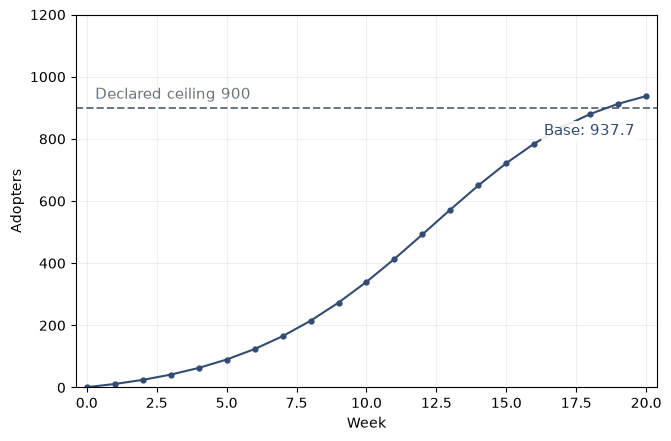

- **Scenario:** Base (imitation 0.30)
- **Adopters at week 20:** 937.7
- **Highest adopters:** 937.7
- **Ceiling:** 900
- **Constraint breaches:** 1

Week 1 adds (0.01 + 0.30 x 1 / 1000) x (1000 - 1) = 10.29 adopters, giving 11.29, and twenty such weeks end at 937.7. Breach: 937.7 - 900 = 37.7 above the ceiling, so the record carries the warning "adopters reached 937.7, above 900.0".

In [11]:
show(scenario_spread(imitation=0.3, ceiling=900.0))

**Use the idea.** Declare the bound the organization cares about before running scenarios, so every run reports against it.

**Where the conclusion applies.** One parameter varied, Euler at a step of 1, twenty weeks, a market of 1000. The result fails to generalise if other parameters, never varied here, also move the outcome.

*Constructed example: the chapter's scenario table, imitation 0.05, 0.30 and 0.60, run with the chapter's ScenarioRunner; the ceiling of 1100 is a value defined for this reader.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(scenario_spread, [('imitation', [0.05, 0.3, 0.6]), ('ceiling', [900.0, 1100.0])])

- **imitation = 0.05, ceiling = 900.0**: Scenario Cautious (imitation 0.05); Adopters at week 20 275.9; Highest adopters 275.9; Ceiling 900; Constraint breaches 0
- **imitation = 0.05, ceiling = 1100.0**: Scenario Cautious (imitation 0.05); Adopters at week 20 275.9; Highest adopters 275.9; Ceiling 1100; Constraint breaches 0
- **imitation = 0.3, ceiling = 900.0**: Scenario Base (imitation 0.30); Adopters at week 20 937.7; Highest adopters 937.7; Ceiling 900; Constraint breaches 1
- **imitation = 0.3, ceiling = 1100.0**: Scenario Base (imitation 0.30); Adopters at week 20 937.7; Highest adopters 937.7; Ceiling 1100; Constraint breaches 0
- **imitation = 0.6, ceiling = 900.0**: Scenario Aggressive (imitation 0.60); Adopters at week 20 1000.0; Highest adopters 1000.0; Ceiling 900; Constraint breaches 1
- **imitation = 0.6, ceiling = 1100.0**: Scenario Aggressive (imitation 0.60); Adopters at week 20 1000.0; Highest adopters 1000.0; Ceiling 1100; Constraint breaches 0

## 2. The settings belong in the record

*Can two scenarios run at different settings be compared as policies?*

The difference in settings moves the answer by a few adopters, which is more than the gap the policy difference makes. The comparison then reflects the solver, not the policies.

    settings=RunSettings(solver="euler", dt=1.0, horizon=20, seed=0)

**Symbols and inputs.** Scenario A has imitation 0.300 and B has 0.302, so B truly has more adopters. B always runs with Euler at a step of 1; A runs with the chosen solver and step.

**Predict first.** If A is run with the fourth-order solver at a step of 1.0, does B still read as higher?

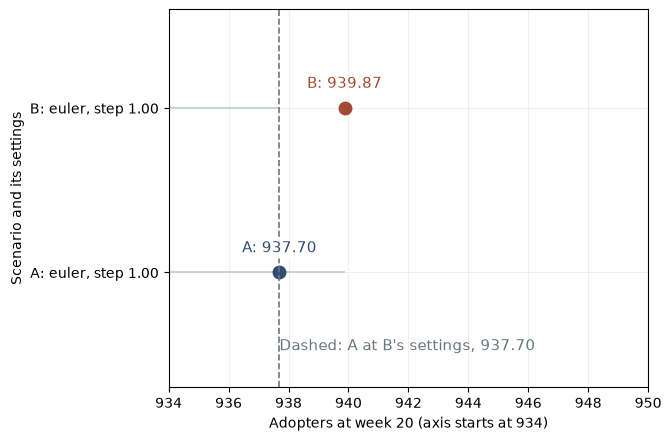

- **A settings:** euler, step 1.00
- **A adopters:** 937.70
- **B adopters (euler, step 1.00):** 939.87
- **B minus A as read:** 2.17
- **B minus A at equal settings:** 2.17
- **Model hash A:** 05bc66d66e9fe2a0
- **Model hash B:** d8a46a6f96bf7fa6

At equal settings B - A = 939.87 - 937.70 = 2.17, so stronger word of mouth (0.302 against 0.300) gives more adopters. As recorded, B - A = 939.87 - 937.70 = 2.17. B reads as higher, which is the true order. The hashes differ because the override differs; the settings travel in the record beside them.

In [13]:
show(replay_settings(solver='euler', dt=1.0))

**Use the idea.** Compare scenarios only when the record shows identical settings, and re-run at equal settings when it does not.

**Where the conclusion applies.** A small true gap of about two adopters, chosen to make the point. A larger policy gap would survive the settings difference.

*Constructed example: the chapter's base scenario, plus a second scenario with a gap chosen for this reader, run with the chapter's ScenarioRunner.*

Every setting the interactive reader offers for this demonstration:

In [14]:
sweep(replay_settings, [('solver', ['euler', 'rk4']), ('dt', [1.0, 0.25])])

- **solver = euler, dt = 1.0**: A settings euler, step 1.00; A adopters 937.70; B adopters (euler, step 1.00) 939.87; B minus A as read 2.17; B minus A at equal settings 2.17; Model hash A 05bc66d66e9fe2a0; Model hash B d8a46a6f96bf7fa6
- **solver = euler, dt = 0.25**: A settings euler, step 0.25; A adopters 941.32; B adopters (euler, step 1.00) 939.87; B minus A as read (-1.44); B minus A at equal settings 2.17; Model hash A 05bc66d66e9fe2a0; Model hash B d8a46a6f96bf7fa6
- **solver = rk4, dt = 1.0**: A settings rk4, step 1.00; A adopters 942.37; B adopters (euler, step 1.00) 939.87; B minus A as read (-2.50); B minus A at equal settings 2.17; Model hash A 05bc66d66e9fe2a0; Model hash B d8a46a6f96bf7fa6
- **solver = rk4, dt = 0.25**: A settings rk4, step 0.25; A adopters 942.38; B adopters (euler, step 1.00) 939.87; B minus A as read (-2.51); B minus A at equal settings 2.17; Model hash A 05bc66d66e9fe2a0; Model hash B d8a46a6f96bf7fa6

## 3. Averaging scenarios shows a path nobody ran

*What does the average of two scenarios describe?*

The average of two paths is a third path that the model never generated. Reading it as a forecast hides the spread, which is the information the scenarios were run to show.

    overrides={"imitation": 0.60}

**Symbols and inputs.** Each line is one scenario, set by its imitation override. The dashed line is the plain average of the two emphasised lines at each week.

**Predict first.** Averaging the cautious and aggressive scenarios at week 20, is the result near either scenario or between them?

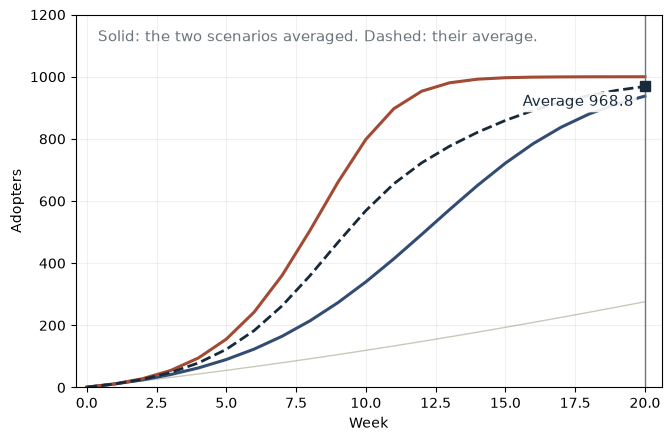

- **Scenarios averaged:** base and aggressive
- **Week read:** 20
- **Base at that week:** 937.7
- **Aggressive at that week:** 1000.0
- **Average:** 968.8
- **Nearest scenario:** Base (937.7) and Aggressive (1000.0) (a tie)
- **Distance to nearest scenario:** 31.1

At week 20: (937.70 + 999.97) / 2 = 968.83, shown as 968.8. The closest of the three scenario values is Base (937.7) and Aggressive (1000.0), a tie, since the average sits halfway between them, at a distance of |968.8 - 937.7| = 31.1. No scenario produced the average, which is why the contract displays the lines side by side.

In [15]:
show(averaged_lines(pair='ba', week=20))

**Use the idea.** Show scenarios as separate lines or a range, and say that no line is a prediction.

**Where the conclusion applies.** Three scenarios and an equal weighting. Any other weighting would also be a path the model never generated.

*Constructed example: the chapter's three scenarios, averaged by this reader to illustrate the dashboard rule; the chapter's code runs the scenarios, the averaging is plain arithmetic.*

Every setting the interactive reader offers for this demonstration:

In [16]:
sweep(averaged_lines, [('pair', ['cb', 'ca', 'ba']), ('week', [10, 20])])

- **pair = cb, week = 10**: Scenarios averaged cautious and base; Week read 10; Cautious at that week 119.5; Base at that week 339.9; Average 229.7; Nearest scenario Cautious (119.5) and Base (339.9) (a tie); Distance to nearest scenario 110.2
- **pair = cb, week = 20**: Scenarios averaged cautious and base; Week read 20; Cautious at that week 275.9; Base at that week 937.7; Average 606.8; Nearest scenario Cautious (275.9) and Base (937.7) (a tie); Distance to nearest scenario 330.9
- **pair = ca, week = 10**: Scenarios averaged cautious and aggressive; Week read 10; Cautious at that week 119.5; Aggressive at that week 798.5; Average 459.0; Nearest scenario Base (339.9); Distance to nearest scenario 119.1
- **pair = ca, week = 20**: Scenarios averaged cautious and aggressive; Week read 20; Cautious at that week 275.9; Aggressive at that week 1000.0; Average 637.9; Nearest scenario Base (937.7); Distance to nearest scenario 299.8
- **pair = ba, week = 10**: Scenarios averaged base and aggressive; Week read 10; Base at that week 339.9; Aggressive at that week 798.5; Average 569.2; Nearest scenario Base (339.9) and Aggressive (798.5) (a tie); Distance to nearest scenario 229.3
- **pair = ba, week = 20**: Scenarios averaged base and aggressive; Week read 20; Base at that week 937.7; Aggressive at that week 1000.0; Average 968.8; Nearest scenario Base (937.7) and Aggressive (1000.0) (a tie); Distance to nearest scenario 31.1

## 4. A narrative may cite only the record

*Which quantities in a proposed narrative does the replay record fail to support?*

The check is a set difference: the names in the narrative minus the names in the record. It is mechanical, so a fluent narrative cannot talk its way past it.

    supported_by_record({"adopters", "marketing_spend"}, record)

**Symbols and inputs.** The record holds the reported outputs and the overrides of one run. A narrative names variables; the check lists names the record does not hold.

**Predict first.** If the narrative names adopters and marketing_spend, which name is flagged?

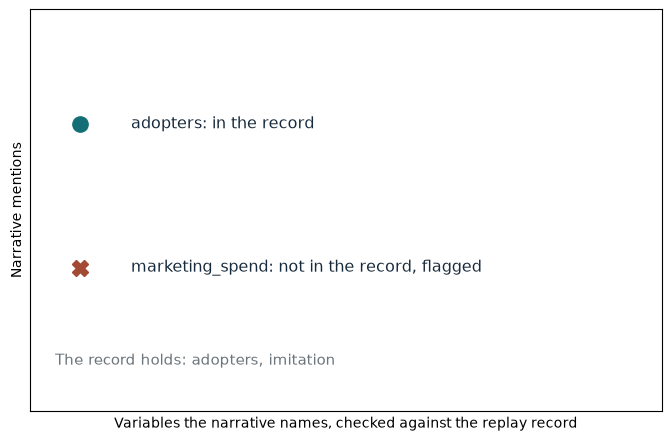

- **Record holds:** adopters, imitation
- **Narrative names:** adopters, marketing_spend
- **Flagged as unsupported:** marketing_spend

Names {adopters, marketing_spend} minus the record {adopters, imitation} leaves ['marketing_spend']: 2 - 1 = 1 flagged. A narrative citing these quantities is rejected rather than edited.

In [17]:
show(narrative_check(mention='b', overrides='one'))

**Use the idea.** Reject a narrative that cites quantities the run never produced, instead of editing it.

**Where the conclusion applies.** Only names are checked. A name in the record can still be described wrongly, and the check does not read the sentence.

*Constructed example: the chapter's aggressive scenario, with the narrative name sets and the second override defined for this reader, checked with the chapter's supported_by_record.*

Every setting the interactive reader offers for this demonstration:

In [18]:
sweep(narrative_check, [('mention', ['a', 'b', 'c', 'd']), ('overrides', ['one', 'two'])])

- **mention = a, overrides = one**: Record holds adopters, imitation; Narrative names adopters; Flagged as unsupported none (nothing flagged)
- **mention = a, overrides = two**: Record holds adopters, imitation, total_market; Narrative names adopters; Flagged as unsupported none (nothing flagged)
- **mention = b, overrides = one**: Record holds adopters, imitation; Narrative names adopters, marketing_spend; Flagged as unsupported marketing_spend
- **mention = b, overrides = two**: Record holds adopters, imitation, total_market; Narrative names adopters, marketing_spend; Flagged as unsupported marketing_spend
- **mention = c, overrides = one**: Record holds adopters, imitation; Narrative names adopters, imitation; Flagged as unsupported none (nothing flagged)
- **mention = c, overrides = two**: Record holds adopters, imitation, total_market; Narrative names adopters, imitation; Flagged as unsupported none (nothing flagged)
- **mention = d, overrides = one**: Record holds adopters, imitation; Narrative names adopters, imitation, marketing_spend, total_market; Flagged as unsupported marketing_spend, total_market
- **mention = d, overrides = two**: Record holds adopters, imitation, total_market; Narrative names adopters, imitation, marketing_spend, total_market; Flagged as unsupported marketing_spend

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

With the ceiling at 1100, how many scenarios breach, and what is the aggressive peak?

<details><summary>Answer</summary>

None. The aggressive scenario peaks at 999.97, which is below 1100, so 999.97 - 1100 is negative and nothing is recorded.

</details>

### Exercise 2

If B had imitation 0.31 (948.0 adopters under Euler at step 1), would the settings difference of A still reverse the order?

<details><summary>Answer</summary>

No. A under rk4 at step 1.0 is 942.37, and 947.95 - 942.37 = 5.58 is positive, so B stays ahead.

</details>

### Exercise 3

At week 20, what is the average of the cautious and base scenarios?

<details><summary>Answer</summary>

(275.9 + 937.7) / 2 = 606.8, which is 330.9 from each of them (a tie), so it is near neither.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/